## **1. Import Libraries**
---

In [2]:
# Download ICDAR 2003 dataset (~45MB)
# https://drive.google.com/file/d/1kUy2tuH-kKBlFCNA0a9sqD2TG4uyvBnV/view
!gdown 1kUy2tuH-kKBlFCNA0a9sqD2TG4uyvBnV
!unzip -q icdar2003.zip -d datasets

Downloading...
From (original): https://drive.google.com/uc?id=1kUy2tuH-kKBlFCNA0a9sqD2TG4uyvBnV
From (redirected): https://drive.google.com/uc?id=1kUy2tuH-kKBlFCNA0a9sqD2TG4uyvBnV&confirm=t&uuid=d5e86088-5c99-4732-8236-65468f51c19b
To: /kaggle/working/icdar2003.zip
100%|██████████████████████████████████████| 45.7M/45.7M [00:01<00:00, 45.3MB/s]


In [39]:
import os
import time
import random
import xml.etree.ElementTree as ET
from sklearn.model_selection import train_test_split

import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import timm
import torch
import torch.nn as nn
from torch.nn import functional as F
from torch.utils.data import DataLoader, Dataset
import torchvision
from torchvision import transforms

## **2. Extract Data from XML**
---

In [40]:
def extract_data_from_xml(root_dir):
    xml_path = os.path.join(root_dir, "words.xml")
    tree = ET.parse(xml_path)
    root = tree.getroot()

    img_paths, img_sizes, img_labels, bboxes = [], [], [], []
    for img in root:
        bbs_of_img    = []
        labels_of_img = []

        for bbs in img.findall("taggedRectangles"):
            for bb in bbs:
                
                if not bb[0].text.isalnum():
                    continue
                if "é" in bb[0].text.lower() or "ñ" in bb[0].text.lower():
                    continue

                bbs_of_img.append([
                    float(bb.attrib["x"]),
                    float(bb.attrib["y"]),
                    float(bb.attrib["width"]),
                    float(bb.attrib["height"]),
                ])
                labels_of_img.append(bb[0].text.lower())

        img_path = os.path.join(root_dir, img[0].text)
        img_paths.append(img_path)
        img_sizes.append((int(img[1].attrib["x"]), int(img[1].attrib["y"])))
        bboxes.append(bbs_of_img)
        img_labels.append(labels_of_img)

    return img_paths, img_sizes, img_labels, bboxes

In [41]:
dataset_dir = "datasets/SceneTrialTrain"

img_paths, img_sizes, img_labels, bboxes = extract_data_from_xml(dataset_dir)

In [42]:
print(f"Number of images        : {len(img_paths)}")
print(f"Number of bounding boxes: {sum([len(bbs) for bbs in bboxes])}")

Number of images        : 250
Number of bounding boxes: 1097


## **3. Prepare Dataset**
---

In [43]:
def split_bounding_boxes(img_paths, img_labels, bboxes, save_dir):
    os.makedirs(save_dir, exist_ok=True)

    count  = 0
    labels = []

    for img_path, img_label, bbs in zip(img_paths, img_labels, bboxes):
        img = Image.open(img_path)

        for label, bb in zip(img_label, bbs):
            cropped_img = img.crop((bb[0], bb[1], bb[0] + bb[2], bb[1] + bb[3]))
            if np.mean(cropped_img) < 35 or np.mean(cropped_img) > 220:
                continue
            if cropped_img.size[0] < 10 or cropped_img.size[1] < 10:
                continue

            filename = f"{count:06d}.jpg"
            cropped_img.save(os.path.join(save_dir, filename))
            
            new_img_path = os.path.join(save_dir, filename)
            label        = new_img_path + "\t" + label
            labels.append(label)

            count += 1

    with open(os.path.join(save_dir, "labels.txt"), "w") as f:
        for label in labels:
            f.write(f"{label}\n")

In [44]:
save_dir = "datasets/ocr_dataset"

split_bounding_boxes(img_paths, img_labels, bboxes, save_dir)

In [45]:
root_dir = save_dir

img_paths = []
labels    = []
with open(os.path.join(root_dir, "labels.txt"), "r") as f:
    for label in f:
        labels.append(label.strip().split("\t")[1])
        img_paths.append(label.strip().split("\t")[0])

print(f"Total images: {len(img_paths)}")

Total images: 1088


## **4. Prepare Vocabulary**
---

In [46]:
letters = [char.split(".")[0].lower() for char in labels]
letters = "".join(letters)
letters = sorted(list(set(list(letters))))

chars       = "".join(letters)
blank_char  = "-"
chars      += blank_char
vocab_size  = len(chars)

char_to_idx = {char: idx + 1 for idx, char in enumerate(sorted(chars))}
idx_to_char = {idx: char for char, idx in char_to_idx.items()}

max_label_len = max([len(label) for label in labels])

print(f"Vocab           : {chars}")
print(f"Vocab size      : {vocab_size}")
print(f"Max label length: {max_label_len}")

Vocab           : 0123456789abcdefghijklmnopqrstuvwxyz-
Vocab size      : 37
Max label length: 14


In [47]:
def encode(label, char_to_idx, max_label_len):
    encoded_labels = torch.tensor([char_to_idx[char] for char in label], dtype=torch.long)
    label_len      = len(encoded_labels)
    lengths        = torch.tensor(label_len, dtype=torch.long)
    padded_labels  = F.pad(encoded_labels, (0, max_label_len - label_len), value=0)

    return padded_labels, lengths

In [48]:
def decode(encoded_sequences, idx_to_char, blank_char="-"):
    decoded_sequences = []

    for seq in encoded_sequences:
        decoded_label = []
        prev_char = None

        for token in seq:
            if token != 0:  # Ignore padding (token = 0)
                char = idx_to_char[token.item()]
               
                if char != blank_char:  # Append the character if it's not a blank or the same as the previous character
                    if char != prev_char or prev_char == blank_char:
                        decoded_label.append(char)
                prev_char = char

        decoded_sequences.append("".join(decoded_label))
        
    return decoded_sequences

## **5. Create PyTorch Dataset**
---

In [49]:
data_transforms = {
    "train": transforms.Compose([
        transforms.Resize((100, 420)),
        transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5,),
        transforms.Grayscale(num_output_channels=1,),
        transforms.GaussianBlur(3),
        transforms.RandomAffine(degrees=1, shear=1,),
        transforms.RandomPerspective(distortion_scale=0.3, p=0.5, interpolation=3,),
        transforms.RandomRotation(degrees=2),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,)),
    ]),
    "val": transforms.Compose([
        transforms.Resize((100, 420)),
        transforms.Grayscale(num_output_channels=1),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,)),
    ]),
}

In [50]:
X_train, X_val , y_train, y_val  = train_test_split(img_paths, labels, test_size=0.1, random_state=0, shuffle=True,)
X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=0.1, random_state=0, shuffle=True,)

In [51]:
class STRDataset(Dataset):
    def __init__(self, X, y, char_to_idx, max_label_len, label_encoder=None, transform=None,):
        self.transform     = transform
        self.img_paths     = X
        self.labels        = y
        self.char_to_idx   = char_to_idx
        self.max_label_len = max_label_len
        self.label_encoder = label_encoder

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        label    = self.labels[idx]
        img_path = self.img_paths[idx]
        img      = Image.open(img_path).convert("RGB")

        if self.transform:
            img = self.transform(img)
        if self.label_encoder:
            encoded_label, label_len = self.label_encoder(label, self.char_to_idx, self.max_label_len)
            
        return img, encoded_label, label_len

In [52]:
train_dataset = STRDataset(X_train, y_train, char_to_idx=char_to_idx, max_label_len=max_label_len, label_encoder=encode, transform=data_transforms["train"],)
val_dataset   = STRDataset(X_val  , y_val  , char_to_idx=char_to_idx, max_label_len=max_label_len, label_encoder=encode, transform=data_transforms["val"],)
test_dataset  = STRDataset(X_test , y_test , char_to_idx=char_to_idx, max_label_len=max_label_len, label_encoder=encode, transform=data_transforms["val"],)

print(f"Train dataset: {len(train_dataset)}")
print(f"Val   dataset: {len(val_dataset)}")
print(f"Test  dataset: {len(test_dataset)}")

Train dataset: 881
Val   dataset: 109
Test  dataset: 98


In [53]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=128, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=128, shuffle=False)

['smirnof', 'gates', 'ryanair', 'london', 'in', 'push', 'rbon', 'sence', 'bot', 'ofice', '6tb', 'cask', '2n', 'trafic', 'the', 'to', 'being', 'nuisance', '3', 'the', 'clacton', 'mail', 'lock', 'weather', 'use', 'boundary', 'v10', 'dolar', '202', 'sats', 'hire', 'making', 'for', 'house', 'computing', 'edinburg', 'constantine', 'schol', 'libraries', 'design', 'burnside', 'a', 'pres', 'personel', 'e', '2', 'u', 'on', 'omputer', 'london', 'entertaining', 'ancient', '202', 'zubrowka', 'race', 'arena', 'flying', '36', 'chapman', 'information', '4', 'yard', 'design', 'farnborough']


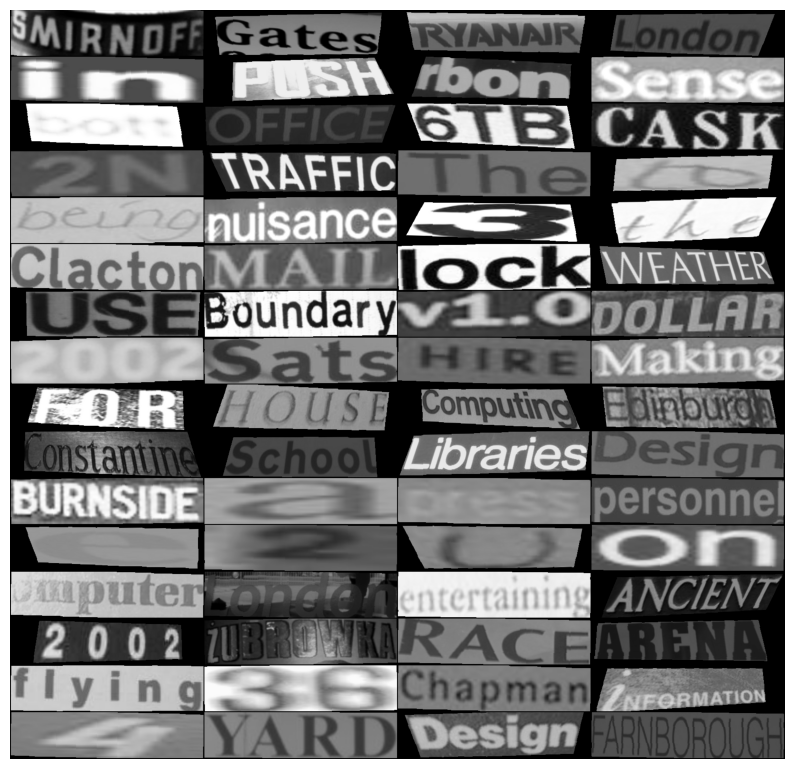

In [54]:
train_features, train_labels, train_lengths = next(iter(train_loader))

labels = decode(train_labels, idx_to_char)
print(labels)

grid = torchvision.utils.make_grid(train_features, nrow=4, normalize=True)
plt.figure(figsize=(10, 20))
plt.imshow(np.transpose(grid, (1, 2, 0)))
plt.axis("off")
plt.show()

## **6. Create Model**
---

In [55]:
class CRNN(nn.Module):
    def __init__(self, vocab_size, hidden_size, n_layers, dropout=0.2, unfreeze_layers=3):
        super(CRNN, self).__init__()

        backbone = timm.create_model("resnet34", in_chans=1, pretrained=True)
        modules  = list(backbone.children())[:-2]
        modules.append(nn.AdaptiveAvgPool2d((1, None)))
        self.backbone = nn.Sequential(*modules)

        for parameter in self.backbone[-unfreeze_layers:].parameters():
            parameter.requires_grad = True

        self.mapSeq = nn.Sequential(nn.Linear(512, 512), nn.ReLU(), nn.Dropout(dropout))
        self.gru = nn.GRU(
            512, hidden_size, n_layers,
            bidirectional=True,
            batch_first=True,
            dropout=dropout if n_layers > 1 else 0,
        )
        self.layer_norm = nn.LayerNorm(hidden_size * 2)
        self.out = nn.Sequential(nn.Linear(hidden_size * 2, vocab_size), nn.LogSoftmax(dim=2))

    @torch.autocast(device_type="cuda")
    def forward(self, x):
        x    = self.backbone(x)
        x    = x.permute(0, 3, 1, 2)
        x    = x.view(x.size(0), x.size(1), -1)
        x    = self.mapSeq(x)
        x, _ = self.gru(x)
        x    = self.layer_norm(x)
        x    = self.out(x)
        x    = x.permute(1, 0, 2)  # Based on CTC

        return x

In [56]:
hidden_size = 256
n_layers = 3
dropout_prob = 0.2
unfreeze_layers = 3
device = "cuda" if torch.cuda.is_available() else "cpu"

model = CRNN(
    vocab_size=vocab_size,
    hidden_size=hidden_size,
    n_layers=n_layers,
    dropout=dropout_prob,
    unfreeze_layers=unfreeze_layers,
).to(device)

## **7. Training & Evaluation**
---

In [57]:
def evaluate(model, dataloader, criterion, device):
    model.eval()
    losses = []
    
    with torch.no_grad():
        for idx, (inputs, labels, labels_len) in enumerate(dataloader):
            inputs     = inputs.to(device)
            labels     = labels.to(device)
            labels_len = labels_len.to(device)

            outputs     = model(inputs)
            logits_lens = torch.full(size=(outputs.size(1),), fill_value=outputs.size(0), dtype=torch.long).to(device)

            loss = criterion(outputs, labels, logits_lens, labels_len)
            losses.append(loss.item())

    loss = sum(losses) / len(losses)
    return loss

In [58]:
def fit(model, train_loader, val_loader, criterion, optimizer, scheduler, device, epochs, max_grad_norm=2):
    train_losses = []
    val_losses   = []

    for epoch in range(epochs):
        start = time.time()

        batch_train_losses = []

        model.train()
        for idx, (inputs, labels, labels_len) in enumerate(train_loader):
            inputs     = inputs.to(device)
            labels     = labels.to(device)
            labels_len = labels_len.to(device)

            optimizer.zero_grad()

            outputs     = model(inputs)
            logits_lens = torch.full(size=(outputs.size(1),), fill_value=outputs.size(0), dtype=torch.long,).to(device)
            loss        = criterion(outputs, labels.cpu(), logits_lens.cpu(), labels_len.cpu())
            loss.backward()

            # Gradient clipping with a configurable max norm
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
            optimizer.step()

            batch_train_losses.append(loss.item())

        train_loss = sum(batch_train_losses) / len(batch_train_losses)
        train_losses.append(train_loss)
        val_loss = evaluate(model, val_loader, criterion, device)
        val_losses.append(val_loss)

        print(f"EPOCH {epoch + 1}:\tTrain loss: {train_loss:.4f}\tVal loss: {val_loss:.4f}\t\t Time: {time.time() - start:.2f} seconds")
        scheduler.step()

    return train_losses, val_losses

In [59]:
epochs       = 100
lr           = 1e-3
weight_decay = 1e-5
scheduler_step_size = epochs * 0.5

criterion = nn.CTCLoss(
    blank=char_to_idx[blank_char],
    zero_infinity=True,
    reduction="mean",
)
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=lr,
    weight_decay=weight_decay,
)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=scheduler_step_size, gamma=0.1)

In [60]:
train_losses, val_losses = fit(model, train_loader, val_loader, criterion, optimizer, scheduler, device, epochs, max_grad_norm=1.0)

EPOCH 1:	Train loss: 4.5731	Val loss: 3.6407		 Time: 7.97 seconds
EPOCH 2:	Train loss: 3.5426	Val loss: 3.7051		 Time: 7.66 seconds
EPOCH 3:	Train loss: 3.4517	Val loss: 3.5199		 Time: 7.87 seconds
EPOCH 4:	Train loss: 3.3906	Val loss: 3.4040		 Time: 7.88 seconds
EPOCH 5:	Train loss: 3.2813	Val loss: 3.4597		 Time: 7.73 seconds
EPOCH 6:	Train loss: 3.1376	Val loss: 3.1775		 Time: 7.46 seconds
EPOCH 7:	Train loss: 2.9531	Val loss: 2.9293		 Time: 7.92 seconds
EPOCH 8:	Train loss: 2.7363	Val loss: 2.8409		 Time: 7.59 seconds
EPOCH 9:	Train loss: 2.4744	Val loss: 2.7509		 Time: 7.63 seconds
EPOCH 10:	Train loss: 2.1853	Val loss: 2.1153		 Time: 7.61 seconds
EPOCH 11:	Train loss: 1.8897	Val loss: 1.9807		 Time: 7.75 seconds
EPOCH 12:	Train loss: 1.5226	Val loss: 1.5114		 Time: 7.57 seconds
EPOCH 13:	Train loss: 1.2883	Val loss: 1.4871		 Time: 7.74 seconds
EPOCH 14:	Train loss: 1.0568	Val loss: 1.4968		 Time: 7.73 seconds
EPOCH 15:	Train loss: 0.9279	Val loss: 1.6767		 Time: 7.91 seconds
EPOC

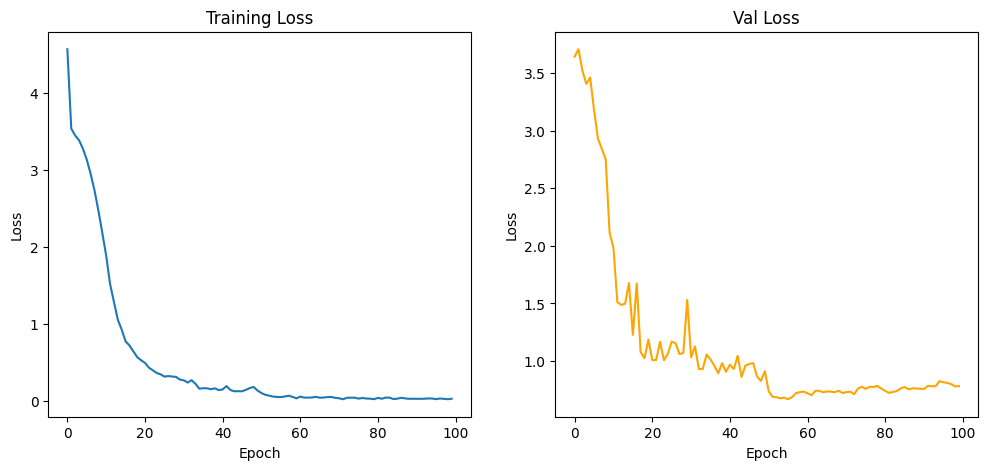

In [61]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(train_losses)
ax[0].set_title("Training Loss")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[1].plot(val_losses, color="orange")
ax[1].set_title("Val Loss")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Loss")
plt.show()

In [62]:
val_loss  = evaluate(model, val_loader, criterion, device)
test_loss = evaluate(model, test_loader, criterion, device)

print("Evaluation on val/test dataset")
print(f"Val  loss: {val_loss}")
print(f"Test loss: {test_loss}")

Evaluation on val/test dataset
Val  loss: 0.7826566696166992
Test loss: 1.1709487438201904


## **8. Inference**
---

In [63]:
def predict(model, img):
    model.eval()
    with torch.no_grad():
        outputs = model(img)
        print(outputs)
        
def decode_label(encoded_sequences, idx_to_char, blank_char="-"):
    decoded_sequences = []

    for seq in encoded_sequences:
        decoded_label = []
        for idx, token in enumerate(seq):
            if token != 0:
                char = idx_to_char[token.item()]
                if char != blank_char:
                    decoded_label.append(char)

        decoded_sequences.append("".join(decoded_label))

    return decoded_sequences

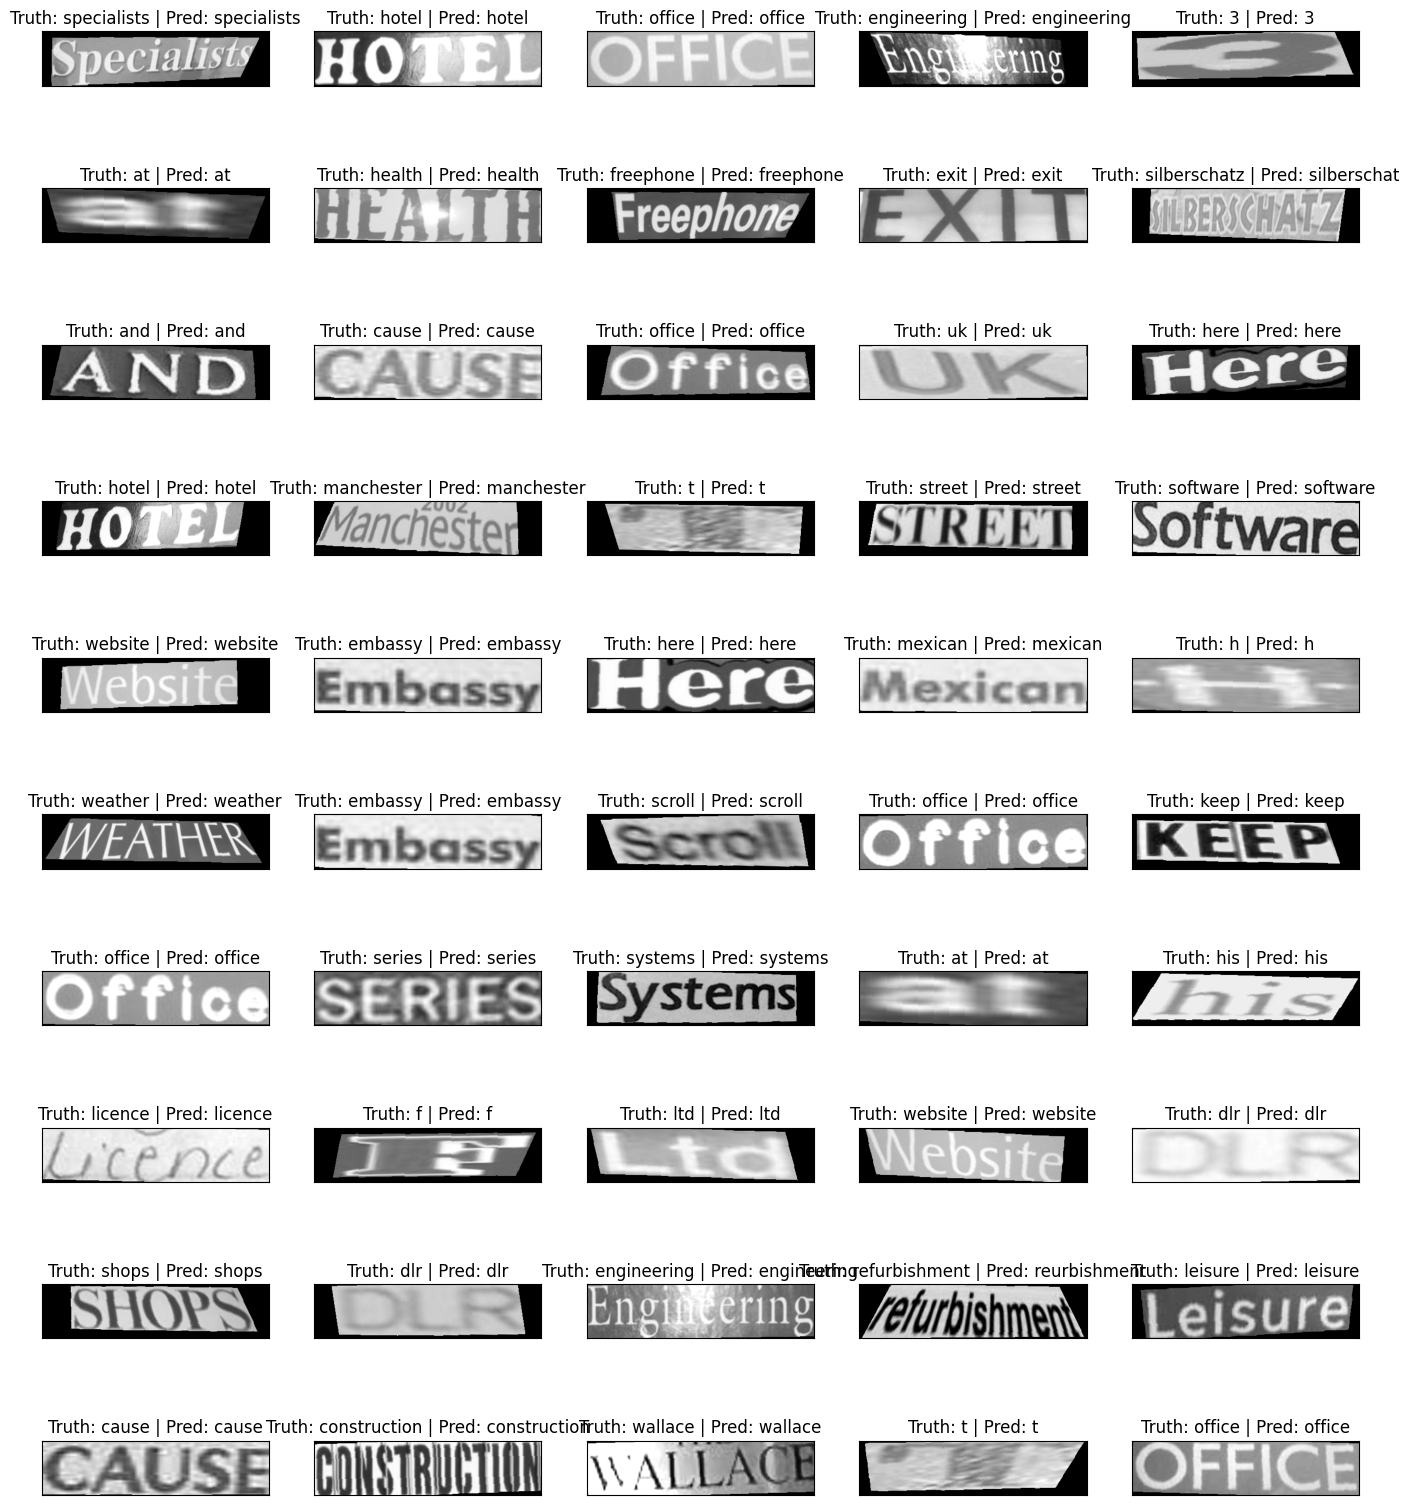

In [64]:
sample_result = []

for i in range(50):
    idx = np.random.randint(len(val_dataset))
    img, label, label_len = train_dataset[idx]
    img = img.to(device)
    label = label.to(device)
    label = decode_label([label], idx_to_char)[0]
    logits = model(img.unsqueeze(0))

    pred_text = decode(logits.permute(1, 0, 2).argmax(2), idx_to_char)[0]

    sample_result.append((img, label, pred_text))

fig = plt.figure(figsize=(17, 20))
for i in range(50):
    ax = fig.add_subplot(10, 5, i + 1, xticks=[], yticks=[])

    img, label, pred_text = sample_result[i]
    img = img.cpu()
    title = f"Truth: {label} | Pred: {pred_text}"

    ax.imshow(img.permute(1, 2, 0), cmap="gray")
    ax.set_title(title)

plt.show()

### Test dataset

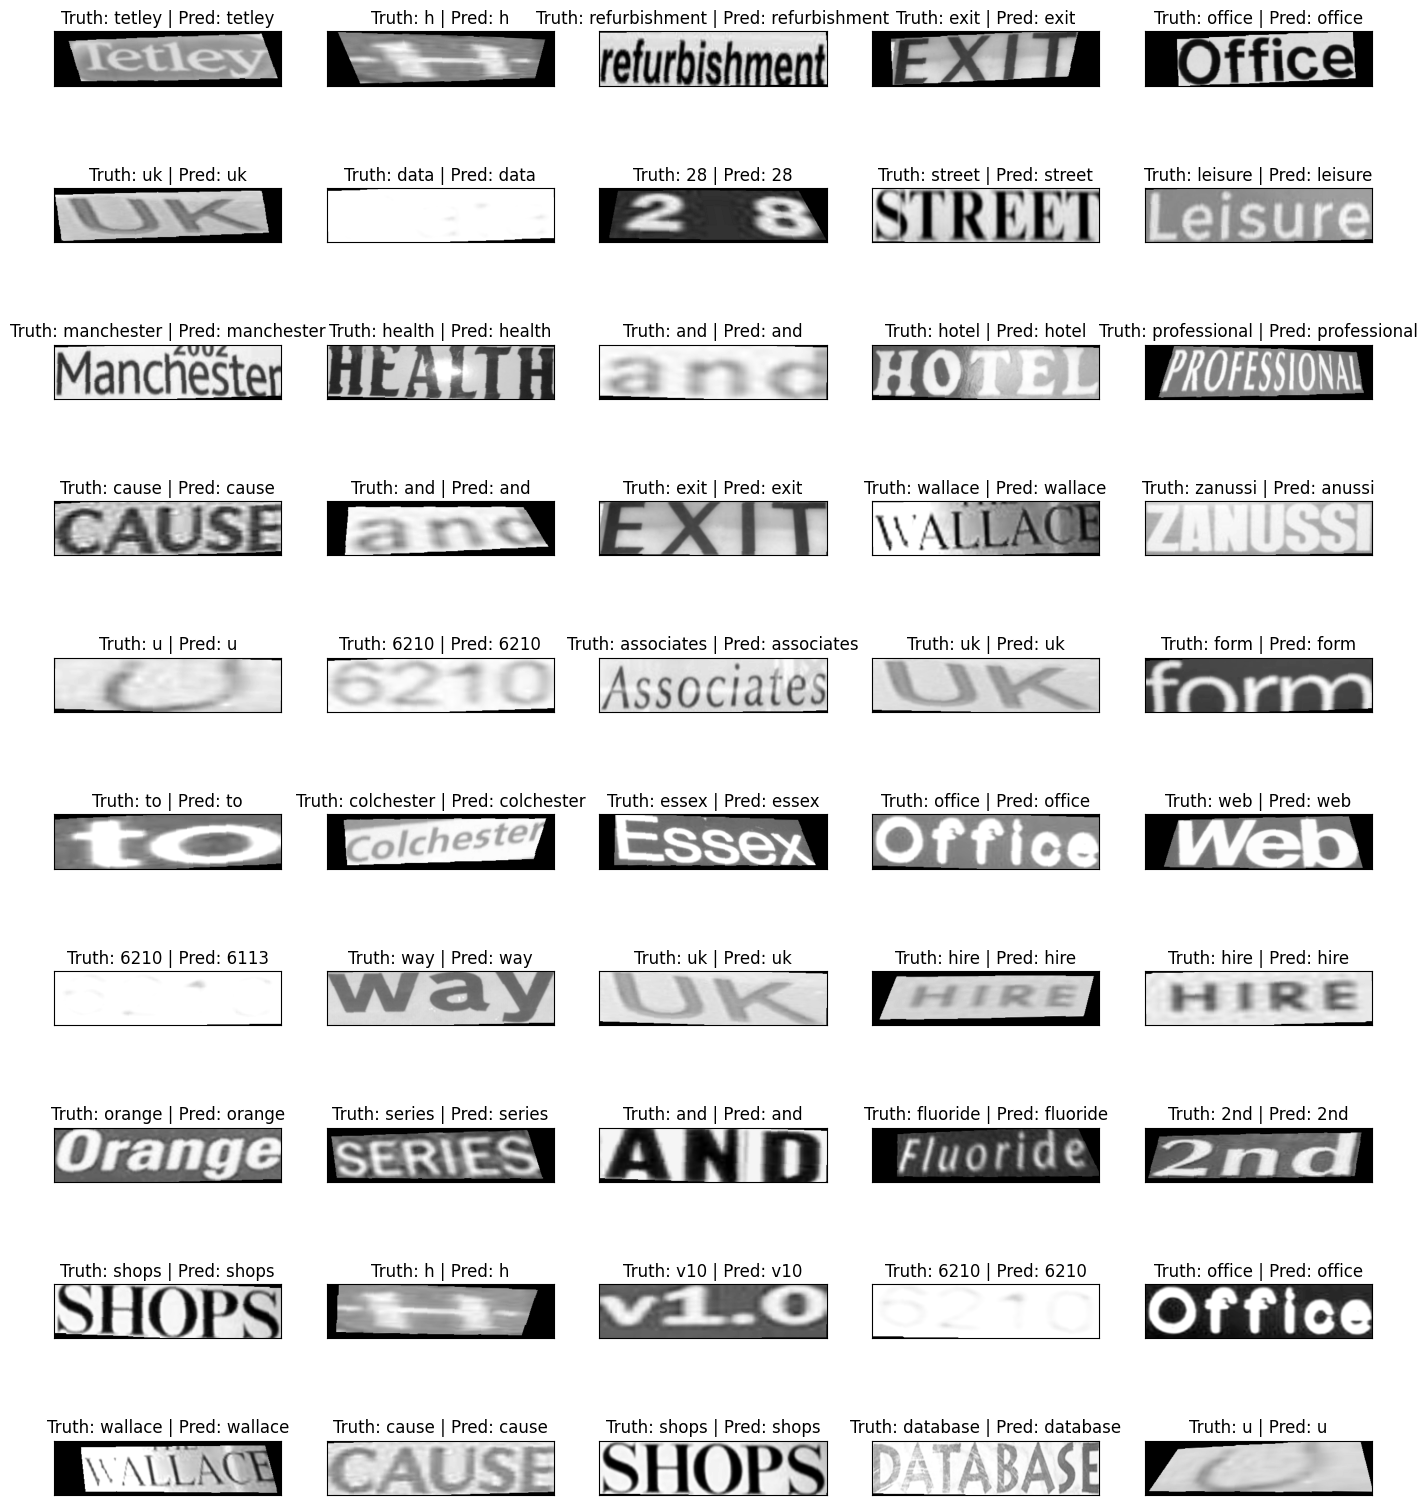

In [65]:
sample_result = []

for i in range(50):
    idx = np.random.randint(len(test_dataset))
    img, label, label_len = train_dataset[idx]
    img = img.to(device)
    label = label.to(device)
    label = decode_label([label], idx_to_char)[0]
    logits = model(img.unsqueeze(0))

    pred_text = decode(logits.permute(1, 0, 2).argmax(2), idx_to_char)[0]

    sample_result.append((img, label, pred_text))

fig = plt.figure(figsize=(17, 20))
for i in range(50):
    ax = fig.add_subplot(10, 5, i + 1, xticks=[], yticks=[])

    img, label, pred_text = sample_result[i]
    img = img.cpu()
    title = f"Truth: {label} | Pred: {pred_text}"

    ax.imshow(img.permute(1, 2, 0), cmap="gray")
    ax.set_title(title)

plt.show()

## **9. Save Model**
---

In [66]:
save_model_path = "ocr_crnn.pt"
torch.save(model.state_dict(), save_model_path)